# Exploratory provjera API-ja

In [21]:
import httpx
import asyncio
from tqdm import tqdm
import os
from dotenv import load_dotenv
load_dotenv()

TOKEN = os.getenv("HTB_API_TOKEN")
class HTBClient:
    def __init__(self, token, max_concurrency=10):
        self.token = token
        self.semaphore = asyncio.Semaphore(max_concurrency)
        self.client = httpx.AsyncClient(
            headers={"Authorization": f"Bearer {token}", "Accept": "application/json"}
        )

    async def get(self, endpoint):
        url = f"https://labs.hackthebox.com/api/v4/{endpoint}"

        async with self.semaphore:  # prevents rate-limit ban
            r = await self.client.get(url, timeout=20)
            r.raise_for_status()
            return r.json()

    async def batch_get(self, endpoints):
        tasks = [self.get(ep) for ep in endpoints]
        results = []
        
        for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
            try:
                results.append(await coro)
            except Exception as e:
                results.append(None)
        return results

In [ ]:
client = HTBClient(TOKEN, max_concurrency=20)
endpoint = "rankings/teams"
await client.get(endpoint)

{'status': True,
 'data': [{'rank': 1,
   'points': 2757,
   'root_owns': 506,
   'user_owns': 506,
   'challenge_owns': 922,
   'root_bloods': 54,
   'user_bloods': 51,
   'challenge_bloods': 30,
   'fortress': 50,
   'id': 6536,
   'name': 'ThugShakers',
   'avatar_thumb_url': 'https://htb-mp-prod-public-storage.s3.eu-central-1.amazonaws.com/teams/9379c23ac12dc94053207373040bc791_thumb.jpg',
   'country': 'KP',
   'ranks_diff': 0},
  {'rank': 2,
   'points': 2609,
   'root_owns': 466,
   'user_owns': 466,
   'challenge_owns': 523,
   'root_bloods': 1,
   'user_bloods': 4,
   'challenge_bloods': 6,
   'fortress': 50,
   'id': 7086,
   'name': 'rpwn',
   'avatar_thumb_url': 'https://htb-mp-prod-public-storage.s3.eu-central-1.amazonaws.com/teams/f8e6ba1db0f3c4054afec1684ba8fb26_thumb.jpg',
   'country': 'US',
   'ranks_diff': 0},
  {'rank': 3,
   'points': 2601,
   'root_owns': 435,
   'user_owns': 438,
   'challenge_owns': 831,
   'root_bloods': 2,
   'user_bloods': 3,
   'challenge_bl

In [ ]:
endpoint = "rankings/users?vip=1"
await client.get(endpoint)

{'status': True,
 'data': [{'rank': 1,
   'points': 16153,
   'root_owns': 505,
   'user_owns': 505,
   'challenge_owns': 801,
   'root_bloods': 0,
   'user_bloods': 0,
   'challenge_bloods': 1,
   'fortress': 50,
   'id': 1246594,
   'name': 'miblak',
   'avatar_thumb': 'https://account.hackthebox.com/storage/users/b0174ec5-dcbd-455a-a7eb-ac541201b775-avatar_thumb.png',
   'country': 'PL',
   'level': 'Omniscient',
   'ranks_diff': 0},
  {'rank': 2,
   'points': 15720,
   'root_owns': 502,
   'user_owns': 502,
   'challenge_owns': 747,
   'root_bloods': 0,
   'user_bloods': 0,
   'challenge_bloods': 0,
   'fortress': 50,
   'id': 19993,
   'name': 'tenflo',
   'avatar_thumb': 'https://account.hackthebox.com/storage/users/bb10c9d3-ed59-49ac-9391-edb5431f4014-avatar_thumb.png',
   'country': 'FR',
   'level': 'Guru',
   'ranks_diff': 0},
  {'rank': 3,
   'points': 14275,
   'root_owns': 501,
   'user_owns': 501,
   'challenge_owns': 265,
   'root_bloods': 0,
   'user_bloods': 0,
   'cha

In [ ]:
endpoint = "team/members/6536"
await client.get(endpoint)

[{'id': 260094,
  'name': 'NLTE',
  'avatar': 'https://account.hackthebox.com/storage/users/5106f57b-8e24-4238-b682-0bf5f1a7baec-avatar.png',
  'rank': 267,
  'points': 810,
  'root_owns': 335,
  'root_bloods_count': 25,
  'user_bloods_count': 17,
  'user_owns': 341,
  'rank_text': 'Guru',
  'country_name': 'Saudi Arabia',
  'country_code': 'SA',
  'role': 'captain',
  'team': {'id': 6536, 'captain_id': 260094},
  'public': 1},
 {'id': 1246594,
  'name': 'miblak',
  'avatar': 'https://account.hackthebox.com/storage/users/3514d737-c06e-46dc-8394-7f24ec57f6d4-avatar.png',
  'rank': 5,
  'points': 2444,
  'root_owns': 505,
  'root_bloods_count': 0,
  'user_bloods_count': 0,
  'user_owns': 505,
  'rank_text': 'Omniscient',
  'country_name': 'Poland',
  'country_code': 'PL',
  'role': 'member',
  'team': {'id': 6536, 'captain_id': 260094},
  'public': 1},
 {'id': 357237,
  'name': 'Sm1l3z',
  'avatar': 'https://account.hackthebox.com/storage/users/b8c2385e-784d-45c0-becd-dbd7f5bcbd6f-avatar

In [ ]:
endpoint = "profile/progress/challenges/87804" # OVO JE ONO ŠTO TREBAM, radi samo za javne profile
await client.get(endpoint)

{'profile': {'solved_tasks': 0,
  'challenge_owns': {'solved': 246, 'total': 801, 'percentage': 31},
  'challenge_categories': [{'name': 'Reversing',
    'owned_flags': 25,
    'total_flags': 97,
    'completion_percentage': 26,
    'avg_user_solved': 2.73},
   {'name': 'Crypto',
    'owned_flags': 37,
    'total_flags': 129,
    'completion_percentage': 29,
    'avg_user_solved': 2.08},
   {'name': 'Pwn',
    'owned_flags': 43,
    'total_flags': 132,
    'completion_percentage': 33,
    'avg_user_solved': 2.52},
   {'name': 'Web',
    'owned_flags': 64,
    'total_flags': 161,
    'completion_percentage': 40,
    'avg_user_solved': 2.56},
   {'name': 'Misc',
    'owned_flags': 23,
    'total_flags': 54,
    'completion_percentage': 43,
    'avg_user_solved': 5.17},
   {'name': 'Forensics',
    'owned_flags': 21,
    'total_flags': 76,
    'completion_percentage': 28,
    'avg_user_solved': 4.05},
   {'name': 'Mobile',
    'owned_flags': 7,
    'total_flags': 21,
    'completion_perce

In [ ]:
endpoint = "profile/260094"
await client.get(endpoint)

{'profile': {'id': 260094,
  'sso_id': True,
  'name': 'NLTE',
  'system_owns': 336,
  'user_owns': 341,
  'user_bloods': 17,
  'system_bloods': 26,
  'challenge_bloods': 2,
  'team': {'id': 6536,
   'name': 'ThugShakers',
   'ranking': 1,
   'avatar': '/teams/9379c23ac12dc94053207373040bc791.jpg',
   'logo_thumb_url': 'https://htb-mp-prod-public-storage.s3.eu-central-1.amazonaws.com/teams/9379c23ac12dc94053207373040bc791_thumb.jpg',
   'member_count': 7},
  'respects': 5246,
  'rank': 'Guru',
  'rank_id': 6,
  'current_rank_progress': 0,
  'next_rank': 'Omniscient',
  'next_rank_points': 49.59,
  'rank_ownership': 49.59,
  'rank_requirement': 90,
  'ranking': 267,
  'avatar': 'https://account.hackthebox.com/storage/users/5106f57b-8e24-4238-b682-0bf5f1a7baec-avatar.png',
  'timezone': 'America/Adak',
  'points': 839,
  'country_name': 'Saudi Arabia',
  'country_code': 'SA',
  'university_name': None,
  'github': None,
  'linkedin': None,
  'twitter': None,
  'joined_date': '2020-02-08T

In [ ]:
endpoint = "profile/activity/260094"
await client.get(endpoint)

{'profile': {'activity': [{'date': '2025-11-29T20:50:58.000000Z',
    'date_diff': '1 day ago',
    'object_type': 'machine',
    'type': 'user',
    'first_blood': False,
    'id': 811,
    'name': 'Gavel',
    'points': 15,
    'machine_avatar': '/avatars/2e446c813e2fa67622764672b9df57bb_thumb.png'},
   {'date': '2025-11-29T20:41:31.000000Z',
    'date_diff': '1 day ago',
    'object_type': 'machine',
    'type': 'root',
    'first_blood': True,
    'id': 811,
    'name': 'Gavel',
    'points': 30,
    'machine_avatar': '/avatars/2e446c813e2fa67622764672b9df57bb_thumb.png'},
   {'date': '2025-11-22T22:14:45.000000Z',
    'date_diff': '1 week ago',
    'object_type': 'machine',
    'type': 'root',
    'first_blood': False,
    'id': 808,
    'name': 'Fries',
    'points': 40,
    'machine_avatar': '/avatars/cf8b89b5cb6d13b0a63831c98086d2be_thumb.png'},
   {'date': '2025-11-22T20:43:36.000000Z',
    'date_diff': '1 week ago',
    'object_type': 'machine',
    'type': 'user',
    'first

# Učitavanje podataka

In [2]:
import pandas as pd
import numpy as np
from typing import Dict
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= json.load(open("../data/raw/challenges_info.json"))
challenges_df = pd.json_normalize(data["challenges"])

In [3]:
teams_df = pd.read_parquet("../data/processed/teams.parquet")
team_members_df = pd.read_json("../data/raw/team_members.jsonl", lines=True)
raw_profiles_df = pd.read_parquet("../data/processed/user_profiles.parquet")

In [4]:
teams_df.head()

,rank,points,root_owns,user_owns,challenge_owns,root_bloods,user_bloods,challenge_bloods,fortress,id,name,avatar_thumb_url,country,ranks_diff
0,1,2757,506,506,922,54,51,30,50,6536,ThugShakers,https://htb-mp-prod-public-storage.s3.eu-centr...,KP,0.0
1,2,2609,466,466,523,1,4,6,50,7086,rpwn,https://htb-mp-prod-public-storage.s3.eu-centr...,US,0.0
2,3,2601,435,438,831,2,3,7,50,5904,ADMinions,https://htb-mp-prod-public-storage.s3.eu-centr...,CA,0.0
3,4,2588,485,485,659,0,1,1,50,6618,Detachment2702,https://htb-mp-prod-public-storage.s3.eu-centr...,AQ,0.0
4,4,2588,448,450,447,8,8,7,50,6900,intrep1dz,https://htb-mp-prod-public-storage.s3.eu-centr...,None,0.0


In [5]:
team_members_df.head()

,id,name,avatar,rank,points,root_owns,root_bloods_count,user_bloods_count,user_owns,rank_text,country_name,country_code,role,team,public,team_id
0,260094,NLTE,https://account.hackthebox.com/storage/users/5...,247,864,336,26,17,342,Guru,Saudi Arabia,SA,captain,"{'id': 6536, 'captain_id': 260094}",1,6536
1,1246594,miblak,https://account.hackthebox.com/storage/users/3...,5,2489,506,0,0,506,Omniscient,Poland,PL,member,"{'id': 6536, 'captain_id': 260094}",1,6536
2,357237,Sm1l3z,https://account.hackthebox.com/storage/users/b...,328,710,394,4,6,394,Guru,Germany,DE,member,"{'id': 6536, 'captain_id': 260094}",1,6536
3,143207,22sh,https://account.hackthebox.com/storage/users/8...,439,550,236,2,3,248,Guru,France,FR,member,"{'id': 6536, 'captain_id': 260094}",1,6536
4,1387134,kapiushion03,None,513,460,194,1,2,194,Pro Hacker,Unknown,None,member,"{'id': 6536, 'captain_id': 260094}",1,6536


In [6]:
raw_profiles_df.head()  

,user_id,profile
0,897946,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."
1,1979263,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."
2,751531,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."
3,860916,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."
4,1667346,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."


In [7]:
challenges_df.head()

,id,name,url_name,retired,difficulty,avg_difficulty,points,static_points,difficulty_chart_arr,solves,...,difficulty_chart.counterCake,difficulty_chart.counterVeryEasy,difficulty_chart.counterEasy,difficulty_chart.counterTooEasy,difficulty_chart.counterMedium,difficulty_chart.counterBitHard,difficulty_chart.counterHard,difficulty_chart.counterTooHard,difficulty_chart.counterExHard,difficulty_chart.counterBrainFuck
0,39,Reminiscent,reminiscent,False,Easy,39,30,30,"[1191, 1367, 3318, 2868, 2611, 1021, 521, 150,...",13241,...,1191,1367,3318,2868,2611,1021,521,150,67,139
1,59,Cryptohorrific,cryptohorrific,False,Medium,45,40,40,"[394, 399, 953, 1367, 1604, 743, 432, 147, 66,...",6126,...,394,399,953,1367,1604,743,432,147,66,115
2,72,Debugme,debugme,False,Medium,47,40,40,"[274, 227, 610, 863, 1361, 646, 372, 119, 45, 93]",4515,...,274,227,610,863,1361,646,372,119,45,93
3,84,Obscure,obscure,False,Easy,43,30,30,"[357, 480, 1316, 1665, 1477, 636, 449, 154, 64...",6653,...,357,480,1316,1665,1477,636,449,154,64,110
4,93,oBfsC4t10n,obfsc4t10n,False,Hard,58,60,60,"[165, 92, 232, 337, 698, 643, 827, 362, 149, 125]",3567,...,165,92,232,337,698,643,827,362,149,125


## Popravljanje gniježđenja u user_profiles tablici

In [8]:
summary_rows = []
category_rows = []
difficulty_rows = []
from ast import literal_eval
for _, row in raw_profiles_df.iterrows():
    uid = row["user_id"]
    profile = literal_eval(bytes.decode(row["profile"]))

    # --- (1) Summary
    owns = profile["challenge_owns"]
    summary_rows.append({
        "id": uid,
        "solved_tasks": profile.get("solved_tasks"),
        "challenge_owns_solved": owns.get("solved"),
        "challenge_owns_total": owns.get("total"),
        "challenge_owns_percentage": owns.get("percentage"),
    })

    # --- (2) Categories
    for c in profile.get("challenge_categories", []):
        category_rows.append({
            "id": uid,
            "category": c.get("name"),
            "owned_flags": c.get("owned_flags") or c.get("owned_challenges"),
            "total_flags": c.get("total_flags") or c.get("total_challenges"),
            "completion_percentage": c.get("completion_percentage"),
            "avg_user_solved": c.get("avg_user_solved"),
        })

    # --- (3) Difficulties
    for d in profile.get("challenge_difficulties", []):
        difficulty_rows.append({
            "id": uid,
            "difficulty": d.get("name"),
            "owned_challenges": d.get("owned_challenges"),
            "total_challenges": d.get("total_challenges"),
            "completion_percentage": d.get("completion_percentage"),
        })

# Convert to DataFrames
users_summary_df = pd.DataFrame(summary_rows)
users_categories_df = pd.DataFrame(category_rows)
users_difficulties_df = pd.DataFrame(difficulty_rows)

## Standardizacija

In [21]:
teams_df["id"] = teams_df["id"].astype(str)
team_members_df["team_id"] = team_members_df["team_id"].astype(str)

team_members_df["id"] = team_members_df["id"].astype(str)
users_categories_df["id"] = users_categories_df["id"].astype(str)
users_difficulties_df["id"] = users_difficulties_df["id"].astype(str)
users_summary_df["id"] = users_summary_df["id"].astype(str)

In [14]:
pd.DataFrame.to_parquet(users_summary_df, "../data/processed/users_summary.parquet", index=False)
pd.DataFrame.to_parquet(users_categories_df, "../data/processed/users_categories.parquet", index=False)
pd.DataFrame.to_parquet(users_difficulties_df, "../data/processed/users_difficulties.parquet", index=False)

In [15]:
users_summary_df.head()

,id,solved_tasks,challenge_owns_solved,challenge_owns_total,challenge_owns_percentage
0,897946,0,60,801,7
1,1979263,0,21,801,3
2,751531,0,74,801,9
3,860916,0,106,801,13
4,1667346,0,1,801,0


In [16]:
users_categories_df.head()

,id,category,owned_flags,total_flags,completion_percentage,avg_user_solved
0,897946,Reversing,6.0,97,6,2.73
1,897946,Crypto,28.0,129,22,2.08
2,897946,Pwn,2.0,132,2,2.52
3,897946,Web,6.0,161,4,2.56
4,897946,Misc,1.0,54,2,5.17


In [17]:
users_difficulties_df.head()

,id,difficulty,owned_challenges,total_challenges,completion_percentage
0,897946,Very Easy,25,102,25
1,897946,Easy,20,332,6
2,897946,easy,0,1,0
3,897946,Medium,11,255,4
4,897946,Hard,3,92,3


# Analiza podataka

In [3]:
users_difficulties_df = pd.read_parquet("../data/processed/users_difficulties.parquet")
users_categories_df = pd.read_parquet("../data/processed/users_categories.parquet")
users_summary_df = pd.read_parquet("../data/processed/users_summary.parquet")
teams_df = pd.read_parquet("../data/processed/teams.parquet")
team_members_df = pd.read_json("../data/raw/team_members.jsonl", lines=True)

## Pregled kategorija i raspodjele zadataka po kategorijama

Jesu li challenges uopce ista stvar kao ovo sto se rjesavalo i sto se ima u user infu?


In [19]:
users_categories_df[["category", "total_flags", "avg_user_solved"]].drop_duplicates()

,category,total_flags,avg_user_solved
0,Reversing,97,2.73
1,Crypto,129,2.08
2,Pwn,132,2.52
3,Web,161,2.56
4,Misc,54,5.17
5,Forensics,76,4.05
6,Mobile,21,10.37
7,OSINT,11,20.70
8,Hardware,40,5.71
9,GamePwn,13,14.21


## Raspodjela po zemljama

In [50]:
team_members_df.size

45840

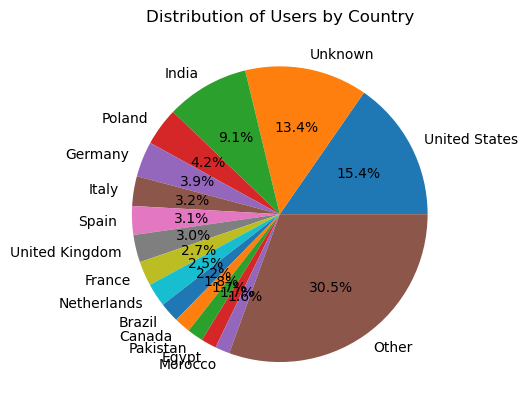

In [ ]:
country_grouped = team_members_df.groupby("country_name").size().sort_values(ascending=False)
treshold = 0.015
big_percentage = country_grouped[country_grouped / country_grouped.sum() >= treshold]
other_percentage = country_grouped[country_grouped / country_grouped.sum() < treshold]
big_percentage["Other"] = other_percentage.sum()
plt.pie(big_percentage, labels=big_percentage.index, autopct='%1.1f%%')
plt.title('Distribution of Users by Country')
plt.show()

In [ ]:
#other countries
other_percentage.index

Index(['Australia', 'Indonesia', 'Ukraine', 'Vietnam', 'Romania', 'Sri Lanka',
       'Argentina', 'China', 'Switzerland', 'Tunisia',
       ...
       'New Caledonia', 'North Korea', 'Mali', 'Malta', 'Monaco',
       'Christmas Island', 'Botswana', 'British Virgin Islands', 'Uzbekistan',
       'Uruguay'],
      dtype='object', name='country_name', length=130)

## Team size

In [96]:
team_size_data = team_members_df.groupby("team_id").size()
team_size_data.describe()

count    112.000000
mean      25.580357
std       79.589107
min        1.000000
25%        5.750000
50%       10.000000
75%       20.250000
max      758.000000
dtype: float64

In [51]:
team_size_data.sort_values()

team_id
3766      1
7280      1
7317      1
394       1
5645      1
       ... 
6789     78
6575     84
6462    126
2102    369
6003    758
Length: 112, dtype: int64

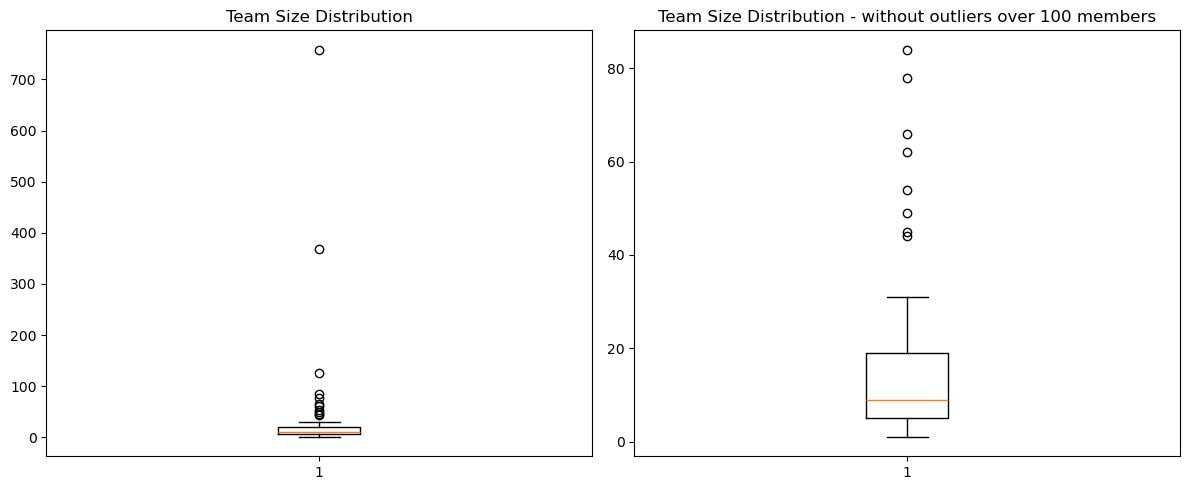

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

upper_bound = 100
filtered = team_size_data[team_size_data <= upper_bound]

axes[0].boxplot(team_size_data)
axes[0].set_title('Team Size Distribution')
axes[1].boxplot(filtered)
axes[1].set_title('Team Size Distribution - without outliers over 100 members')

plt.tight_layout()
plt.show()


## Odnos ranga tima i ranga članova tima

Doduše, ovo je statistika na 100 najboljih timova i njihovih 900-ish neanonimnih članova pa ima smisla da su svi relativno dobri

In [71]:
df1_slim = team_members_df[["id", "name", "rank", "points", "team_id", "role"]]
df2_slim = teams_df[["id", "name", "rank", "points"]]
rank_statistics = df1_slim.merge(df2_slim, left_on="team_id", right_on="id", suffixes=("_user", "_team"))
rank_statistics

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
0,260094,NLTE,247,864,6536,captain,6536,ThugShakers,1,2757
1,1246594,miblak,5,2489,6536,member,6536,ThugShakers,1,2757
2,357237,Sm1l3z,328,710,6536,member,6536,ThugShakers,1,2757
3,143207,22sh,439,550,6536,member,6536,ThugShakers,1,2757
4,1387134,kapiushion03,513,460,6536,member,6536,ThugShakers,1,2757
...,...,...,...,...,...,...,...,...,...,...
2860,523428,GetRektBoy724,unranked,0,5768,member,5768,HCS,100,1062
2861,2782348,erzy,unranked,0,5768,member,5768,HCS,100,1062
2862,1225341,Zumpyx,562,401,6676,captain,6676,CyberFourier,100,1062
2863,1487037,Lusowen,218,942,6676,member,6676,CyberFourier,100,1062


U tablici je 2865 redaka tj. natjecatelja, ali je maksimalni rang 943. To je zato što se rank dijeli među natjecateljima s istim brojem bodova i dodatno postoji 930 natjecatelja s rankom 943. Većina njih ima 0 bodova, ali ne razumijem zašto postoji 176 natejcatelja koji imaju više od 0 bodova, ali su svejedno ranka 943.

In [72]:
rank_statistics[rank_statistics["rank_user"] == 943]

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
82,2761,lynx,943,2,1709,member,1709,WinBARs,6,2570
83,8781,0x5a,943,15,1709,member,1709,WinBARs,6,2570
84,16234,chirality,943,23,1709,member,1709,WinBARs,6,2570
85,40613,MADE,943,0,1709,member,1709,WinBARs,6,2570
86,55159,raiden99,943,0,1709,member,1709,WinBARs,6,2570
...,...,...,...,...,...,...,...,...,...,...
2856,1863416,anarchistxxx,943,0,5768,member,5768,HCS,100,1062
2857,1996861,mintcocs,943,1,5768,member,5768,HCS,100,1062
2858,2163976,honque,943,0,5768,member,5768,HCS,100,1062
2859,2318132,TinyTidy,943,0,5768,member,5768,HCS,100,1062


In [73]:
rank_statistics[(rank_statistics["rank_user"] == 943) & (rank_statistics["points_user"] > 0)]

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
82,2761,lynx,943,2,1709,member,1709,WinBARs,6,2570
83,8781,0x5a,943,15,1709,member,1709,WinBARs,6,2570
84,16234,chirality,943,23,1709,member,1709,WinBARs,6,2570
88,122838,Imm0,943,580,1709,member,1709,WinBARs,6,2570
89,124247,kosinw,943,4,1709,member,1709,WinBARs,6,2570
...,...,...,...,...,...,...,...,...,...,...
2789,833625,SecurityEagle,943,1,4161,member,4161,L3G10N,97,1085
2795,1373600,Cosmoxe,943,3,4161,member,4161,L3G10N,97,1085
2835,111344,Rumo,943,27,5490,member,5490,OPTIMA,99,1064
2836,113741,phate32,943,16,5490,member,5490,OPTIMA,99,1064


In [77]:
rank_statistics.loc[rank_statistics["rank_user"] == 'unranked', "rank_user"] = np.nan

In [78]:
rank_statistics["rank_user"]

0       247
1         5
2       328
3       439
4       513
       ... 
2860    NaN
2861    NaN
2862    562
2863    218
2864    943
Name: rank_user, Length: 2865, dtype: object

Text(0.5, 1.0, 'User Rank vs Team Rank (excluding largest teams and zero points)')

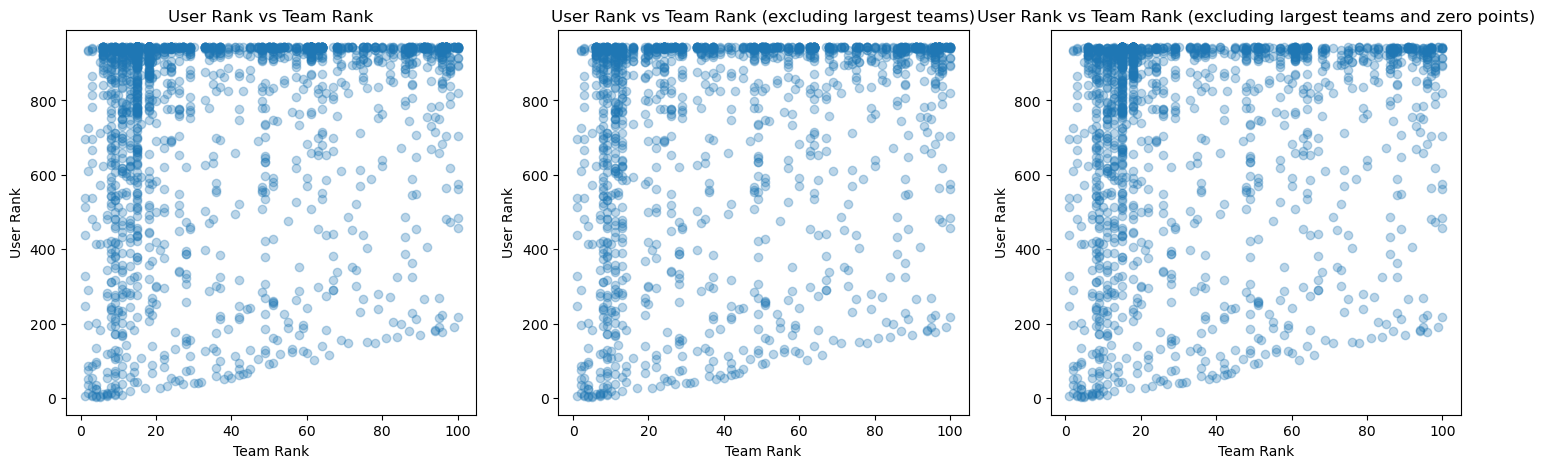

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(rank_statistics["rank_team"], rank_statistics["rank_user"], alpha=0.3)
axes[0].set_xlabel("Team Rank")
axes[0].set_ylabel("User Rank")
axes[0].set_title("User Rank vs Team Rank")

# largest teams:
# 6462    126
# 2102    369
# 6003    758
rank_statistics_no_outliers = rank_statistics[~rank_statistics["id_team"].isin([6003, 2102, 6462])]
axes[1].scatter(rank_statistics_no_outliers["rank_team"], rank_statistics_no_outliers["rank_user"], alpha=0.3)
axes[1].set_xlabel("Team Rank")
axes[1].set_ylabel("User Rank")
axes[1].set_title("User Rank vs Team Rank (excluding largest teams)")

rank_statistics_no_0_points = rank_statistics[rank_statistics["points_user"] > 0]
axes[2].scatter(rank_statistics_no_0_points["rank_team"], rank_statistics_no_0_points["rank_user"], alpha=0.3)
axes[2].set_xlabel("Team Rank")
axes[2].set_ylabel("User Rank")
axes[2].set_title("User Rank vs Team Rank (excluding largest teams and zero points)")

In [79]:
rank_correlation = rank_statistics[["rank_user", "rank_team"]].corr()
rank_correlation

,rank_user,rank_team
rank_user,1.000000,0.067334
rank_team,0.067334,1.000000


In [82]:
rank_correlation_no_outliers = rank_statistics_no_outliers[["rank_user", "rank_team"]].corr()
rank_correlation_no_outliers

,rank_user,rank_team
rank_user,1.000000,0.244592
rank_team,0.244592,1.000000


In [85]:
rank_correlation_no_0_points = rank_statistics_no_outliers[rank_statistics_no_outliers["points_user"] > 0][["rank_user", "rank_team"]].corr()
rank_correlation_no_0_points

,rank_user,rank_team
rank_user,1.000000,0.217279
rank_team,0.217279,1.000000


## Odnos ranga i veličine tima

In [132]:
team_rank = teams_df[["id", "rank"]].rename(columns={"rank": "rank_team", "id": "id_team"})
rank_size_statistics = team_rank.merge(team_size_data.rename("team_size"), left_on="id_team", right_index=True)
rank_size_statistics

,id_team,rank_team,team_size
0,6536,1,7
1,7086,2,11
2,5904,3,17
3,6618,4,3
4,6900,4,8
...,...,...,...
107,4161,97,49
108,6821,98,16
109,5490,99,7
110,5768,100,22


In [133]:
team_size_rank_corr = rank_size_statistics['team_size'].corr(rank_size_statistics['rank_team'])
team_size_rank_corr

-0.19219673172538188

In [134]:
rank_size_statistics_no_outliers = rank_size_statistics[~rank_size_statistics["id_team"].isin([6003, 2102, 6462])]
team_size_rank_corr_no_outliers = rank_size_statistics_no_outliers['team_size'].corr(rank_size_statistics_no_outliers['rank_team'])
team_size_rank_corr_no_outliers

-0.25402162336360345

Text(0.5, 1.0, 'Team Size vs Team Rank')

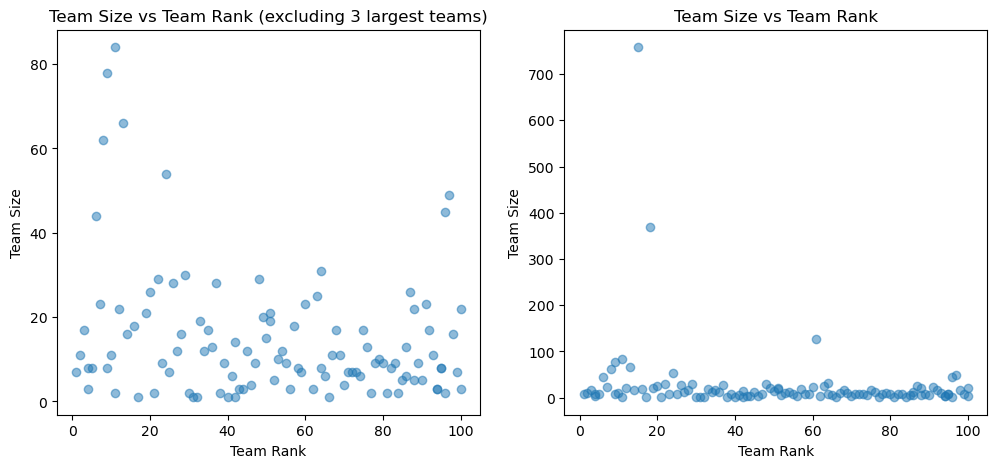

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(rank_size_statistics_no_outliers['rank_team'], rank_size_statistics_no_outliers['team_size'], alpha=0.5)
axes[0].set_xlabel("Team Rank")
axes[0].set_ylabel("Team Size")
axes[0].set_title("Team Size vs Team Rank (excluding 3 largest teams)")

axes[1].scatter(rank_size_statistics["rank_team"], rank_size_statistics['team_size'], alpha=0.5)
axes[1].set_xlabel("Team Rank")
axes[1].set_ylabel("Team Size")
axes[1].set_title("Team Size vs Team Rank")

In [137]:
# Ima li statističke korelacije između veličine tima i ranga tima?
from scipy.stats import spearmanr, pearsonr

rho, p_s = spearmanr(rank_size_statistics['team_size'], rank_size_statistics['rank_team'])
r, p_p = pearsonr(rank_size_statistics['team_size'], rank_size_statistics['rank_team'])
print('Spearman:', rho, p_s)
print('Pearson:', r, p_p)

Spearman: -0.18959730214727222 0.04526337139728963
Pearson: -0.19219673172538176 0.04233934558156263


In [138]:
avg = rank_size_statistics.groupby('team_size')['rank_team'].agg(['mean','count','std']).reset_index()
avg

,team_size,mean,count,std
0,1,38.000000,6,16.309506
1,2,54.750000,8,33.139316
2,3,62.125000,8,32.900011
3,4,58.000000,2,16.970563
4,5,78.750000,4,17.951323
5,6,66.500000,4,19.052559
6,7,57.142857,7,33.178450
7,8,51.500000,8,39.889132
8,9,61.750000,8,24.123196
9,10,66.000000,2,18.384776


Text(0.5, 1.0, 'Average Team Rank vs Team Size with Standard Deviation')

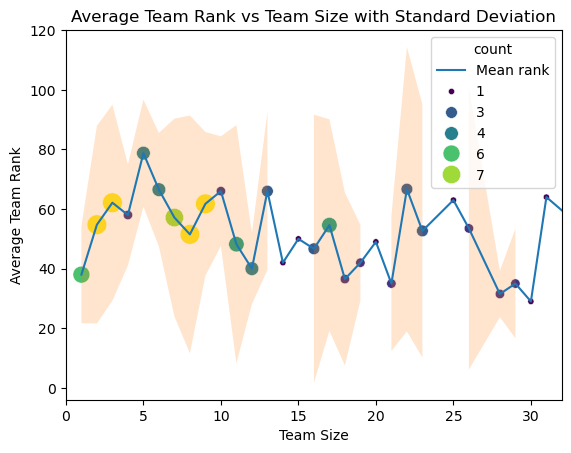

In [141]:
plt.plot(avg['team_size'], avg['mean'], color='C0', label='Mean rank')
sns.scatterplot(
    data=avg,
    x='team_size',
    y='mean',
    size='count',        # map point size to count
    sizes=(20, 200),     # min and max dot size
    hue='count',         # optional: color by count too
    palette='viridis'
)
plt.xlim(0, 32)
plt.fill_between(avg['team_size'], avg['mean'] - avg['std'], avg['mean'] + avg['std'], alpha=0.2, label='±1 SE')
plt.xlabel('Team Size')
plt.ylabel('Average Team Rank')
plt.title('Average Team Rank vs Team Size with Standard Deviation')

## Odnos korisničkih bodova i timskih bodova

In [142]:
team_points = teams_df[["id", "points"]].rename(columns={"points": "points_team", "id": "id_team"})
member_points = team_members_df[["id", "team_id", "points"]].rename(columns={"points": "points_user", "team_id": "id_team", "id": "id_user"})
team_vs_member_points = member_points.merge(team_points, on="id_team")
team_vs_member_points

,id_user,id_team,points_user,points_team
0,260094,6536,864,2757
1,1246594,6536,2489,2757
2,357237,6536,710,2757
3,143207,6536,550,2757
4,1387134,6536,460,2757
...,...,...,...,...
2860,523428,5768,0,1062
2861,2782348,5768,0,1062
2862,1225341,6676,401,1062
2863,1487037,6676,942,1062


<Axes: title={'center': 'User Points vs Team Points'}, xlabel='points_team', ylabel='points_user'>

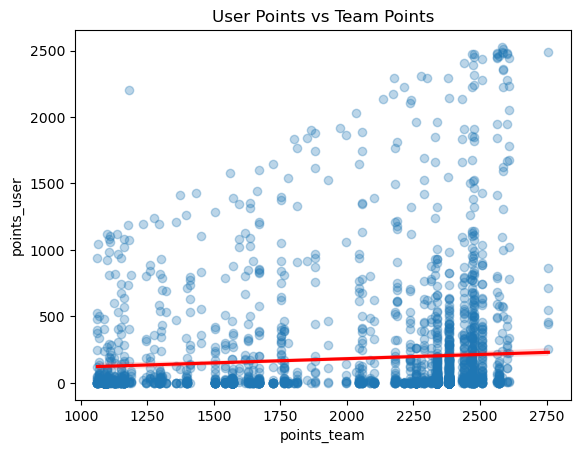

In [153]:
plt.scatter(team_vs_member_points['points_team'], team_vs_member_points['points_user'], alpha=0.3)
plt.xlabel("Team Points")
plt.ylabel("User Points")
plt.title("User Points vs Team Points")
sns.regplot(x='points_team', y='points_user', data=team_vs_member_points, scatter=False, color='red')

In [154]:
corr_points = team_vs_member_points[['points_team', 'points_user']].corr()
corr_points

,points_team,points_user
points_team,1.000000,0.071964
points_user,0.071964,1.000000


## Struktura tima - carry vs. support

## Megamix

In [39]:
merged = (
    team_members_df
    .merge(users_categories_df, on="id")
    .merge(teams_df, left_on="team_id", right_on="id",  suffixes=("_user", "_team"))
)
merged[merged["rank_user"] == 'unranked'] = np.nan
pd.DataFrame.to_parquet(merged, "../data/processed/merged_all.parquet", index=False)

In [70]:
merged = pd.read_parquet("../data/processed/merged_all.parquet")

In [5]:
merged

,id_user,name_user,avatar,rank_user,points_user,root_owns_user,root_bloods_count,user_bloods_count,user_owns_user,rank_text,...,challenge_owns,root_bloods,user_bloods,challenge_bloods,fortress,id_team,name_team,avatar_thumb_url,country,ranks_diff
0,897946,xelitte,https://account.hackthebox.com/storage/users/0...,414.0,591.0,45.0,0.0,0.0,45.0,Pro Hacker,...,356.0,0.0,0.0,0.0,50.0,6565,RaptX,https://htb-mp-prod-public-storage.s3.eu-centr...,AQ,8.0
1,897946,xelitte,https://account.hackthebox.com/storage/users/0...,414.0,591.0,45.0,0.0,0.0,45.0,Pro Hacker,...,356.0,0.0,0.0,0.0,50.0,6565,RaptX,https://htb-mp-prod-public-storage.s3.eu-centr...,AQ,8.0
2,897946,xelitte,https://account.hackthebox.com/storage/users/0...,414.0,591.0,45.0,0.0,0.0,45.0,Pro Hacker,...,356.0,0.0,0.0,0.0,50.0,6565,RaptX,https://htb-mp-prod-public-storage.s3.eu-centr...,AQ,8.0
3,897946,xelitte,https://account.hackthebox.com/storage/users/0...,414.0,591.0,45.0,0.0,0.0,45.0,Pro Hacker,...,356.0,0.0,0.0,0.0,50.0,6565,RaptX,https://htb-mp-prod-public-storage.s3.eu-centr...,AQ,8.0
4,897946,xelitte,https://account.hackthebox.com/storage/users/0...,414.0,591.0,45.0,0.0,0.0,45.0,Pro Hacker,...,356.0,0.0,0.0,0.0,50.0,6565,RaptX,https://htb-mp-prod-public-storage.s3.eu-centr...,AQ,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15067,931176,Rasyy,https://account.hackthebox.com/storage/users/4...,943.0,0.0,10.0,0.0,0.0,10.0,Hacker,...,319.0,0.0,0.0,0.0,19.0,5768,HCS,https://htb-mp-prod-public-storage.s3.eu-centr...,ID,-2.0
15068,931176,Rasyy,https://account.hackthebox.com/storage/users/4...,943.0,0.0,10.0,0.0,0.0,10.0,Hacker,...,319.0,0.0,0.0,0.0,19.0,5768,HCS,https://htb-mp-prod-public-storage.s3.eu-centr...,ID,-2.0
15069,931176,Rasyy,https://account.hackthebox.com/storage/users/4...,943.0,0.0,10.0,0.0,0.0,10.0,Hacker,...,319.0,0.0,0.0,0.0,19.0,5768,HCS,https://htb-mp-prod-public-storage.s3.eu-centr...,ID,-2.0
15070,931176,Rasyy,https://account.hackthebox.com/storage/users/4...,943.0,0.0,10.0,0.0,0.0,10.0,Hacker,...,319.0,0.0,0.0,0.0,19.0,5768,HCS,https://htb-mp-prod-public-storage.s3.eu-centr...,ID,-2.0


In [6]:
df_corr = merged[["rank_user", "rank_team"]].corr()

In [105]:
merged["team_rank_bucket"].isna().sum(), merged["team_rank_bucket"].unique()


(368,
 ['1-20', NaN, '21-40', '41-60', '61-80', '81-100']
 Categories (5, object): ['1-20' < '21-40' < '41-60' < '61-80' < '81-100'])

In [7]:
merged["team_rank_bucket"] = pd.cut(merged["rank_team"], bins=5, labels=["1-20", "21-40", "41-60", "61-80", "81-100"])
grouped_team_rank = merged.groupby("team_rank_bucket")

merged_no_outliers["team_rank_bucket"] = pd.qcut(merged_no_outliers["rank_team"], q=5, labels=["1-20", "21-40", "41-60", "61-80", "81-100"]) 

/tmp/ipykernel_146748/2208724779.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_team_rank = merged.groupby("team_rank_bucket")


NameError: name 'merged_no_outliers' is not defined

Text(0.5, 1.0, 'User Rank vs Team Rank (excluding largest teams)')

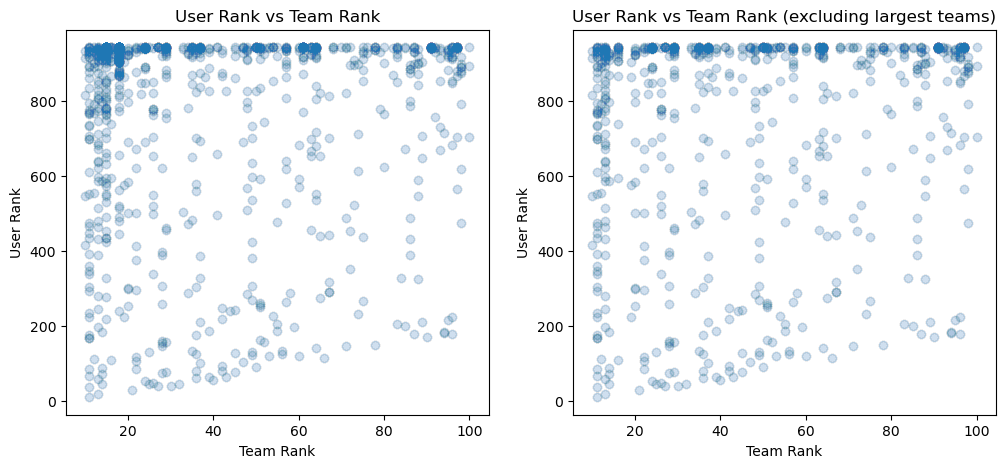

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(merged["rank_team"], merged["rank_user"], alpha=0.01)
axes[0].set_xlabel("Team Rank")
axes[0].set_ylabel("User Rank")
axes[0].set_title("User Rank vs Team Rank")

merged_no_outliers = merged[~merged["id_team"].isin(['6003', '2102', '6462'])]
axes[1].scatter(merged_no_outliers["rank_team"], merged_no_outliers["rank_user"], alpha=0.01)
axes[1].set_xlabel("Team Rank")
axes[1].set_ylabel("User Rank")
axes[1].set_title("User Rank vs Team Rank (excluding largest teams)")


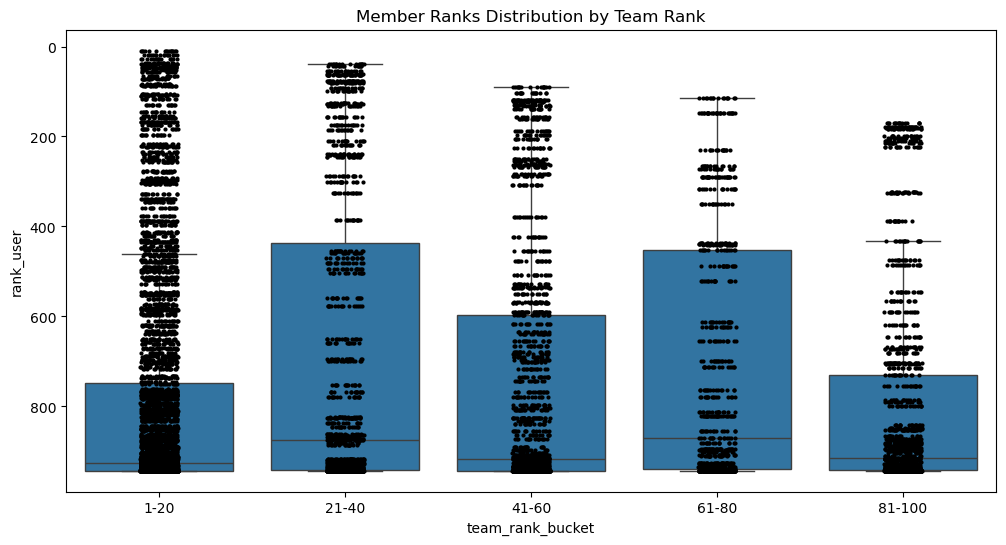

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(data=merged, x="team_rank_bucket", y="rank_user", showfliers=False)
sns.stripplot(data=merged, x="team_rank_bucket", y="rank_user", color="black", size=3, jitter=True)
plt.gca().invert_yaxis()
plt.title("Member Ranks Distribution by Team Rank")
plt.show()

## Team skill grouping 
 za sad je ovo krivo, treba odrediti koliko skillova ima zapravo - tj koliko skupina/stereotipa usera ima

In [ ]:
team_skill_counts = (
    merged.groupby(["id_team", "name_team", "category"])
          .size()
          .reset_index(name="num_users")
)

In [ ]:
team_skill_counts.head()

,id_team,name_team,category,num_users
0,1205,MvtinaPwn,AI - ML,4
1,1205,MvtinaPwn,Blockchain,4
2,1205,MvtinaPwn,Coding,4
3,1205,MvtinaPwn,Crypto,4
4,1205,MvtinaPwn,Forensics,4


In [ ]:
# VIzualizacija

Skill Strength: “How good is the team at each category?”

In [ ]:
team_skill_strength = (
    merged.groupby(["id_team", "name_team", "category"])["completion_percentage"]
          .mean()
          .reset_index(name="avg_skill")
)
team_skill_strength.head()

,id_team,name_team,category,avg_skill
0,1205,MvtinaPwn,AI - ML,9.75
1,1205,MvtinaPwn,Blockchain,18.75
2,1205,MvtinaPwn,Coding,12.75
3,1205,MvtinaPwn,Crypto,10.00
4,1205,MvtinaPwn,Forensics,9.25


In [ ]:
# Vizualizacija

Identify Specialists vs Generalists

In [ ]:
user_spread = (
    users_categories_df.groupby("id")["completion_percentage"]
                         .apply(lambda s: (s > 0).sum())
                         .reset_index(name="num_categories_engaged")
)

team_member_specialization = (
    team_members_df.merge(user_spread, on="id")
)

team_member_specialization.head()


,id,name,avatar,rank,points,root_owns,root_bloods_count,user_bloods_count,user_owns,rank_text,country_name,country_code,role,team,public,team_id,num_categories_engaged
0,897946,xelitte,https://account.hackthebox.com/storage/users/0...,414,591,45,0,0,45,Pro Hacker,Bulgaria,BG,member,"{'id': 6565, 'captain_id': 1804529}",1,6565,11
1,1979263,ghost9898,https://account.hackthebox.com/storage/users/b...,546,406,90,0,0,90,Pro Hacker,Australia,AU,member,"{'id': 6565, 'captain_id': 1804529}",1,6565,4
2,751531,partywave,https://account.hackthebox.com/storage/users/1...,815,132,89,0,0,93,Hacker,Italy,IT,member,"{'id': 6565, 'captain_id': 1804529}",1,6565,12
3,860916,Civiled,https://account.hackthebox.com/storage/users/4...,915,29,32,0,0,46,Hacker,United States,US,member,"{'id': 6565, 'captain_id': 1804529}",1,6565,12
4,1667346,H4rb,https://account.hackthebox.com/storage/users/8...,933,11,101,0,0,101,Pro Hacker,Spain,ES,member,"{'id': 6565, 'captain_id': 1804529}",1,6565,1


In [ ]:
# Vizualizacija

In [ ]:
team_specialization_distribution = (
    team_member_specialization.groupby("team_id")["num_categories_engaged"]
                              .mean()
)
team_specialization_distribution.head()

team_id
1205    11.500000
1443     7.400000
1553     7.000000
2089     5.333333
2102     5.162963
Name: num_categories_engaged, dtype: float64

Role clustering

In [ ]:
skill_matrix = (
    users_categories_df.pivot_table(
        index="id",
        columns="category",
        values="completion_percentage",
        fill_value=0
    )
)

from sklearn.cluster import KMeans

# kako znam broj clustera, sta ne bih trebala raditi nekakvu provjeru broja clustera
skill_matrix["role"] = KMeans(n_clusters=5).fit_predict(skill_matrix)

In [ ]:
skill_matrix.head()

category,AI - ML,Blockchain,Coding,Crypto,Forensics,GamePwn,Hardware,ICS,Misc,Mobile,OSINT,Pwn,Quantum,Reversing,Secure Coding,Web,role
id,,,,,,,,,,,,,,,,,
1001444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1001763,0.0,13.0,25.0,4.0,3.0,15.0,10.0,0.0,2.0,10.0,55.0,2.0,75.0,3.0,33.0,4.0,1
1006675,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1007696,0.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,6.0,0
1009617,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,0


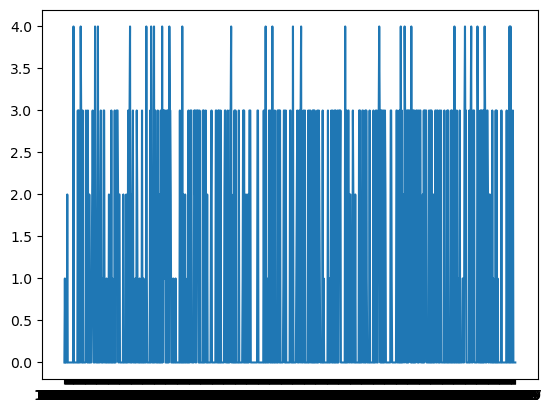

In [ ]:
import matplotlib.pyplot as plt
plt.plot(skill_matrix["role"])

In [ ]:
team_roles = (
    team_members_df.merge(skill_matrix["role"], on="id")
)
team_roles.head()   
team_role_counts = (
    team_roles.groupby(["team_id", "role_y"]).size()
)